# 04 — Random Forest, SHAP, and Partial Dependence

**ML-Assisted Electrochemical Descriptor Analysis of Plasmonic Ag/Au g-C3N4 Photocatalysts**

Predictive modeling of photocurrent (`J_m0p7`) on the full master table:

- Random Forest with grouped LOOCV validation
- SHAP feature attribution on the RF fit (exploratory — see caveat in Section 4)
- Partial dependence plots for the top RF features
- A summary comparing RF against the validated GPR/LASSO results from Notebook 05

**Input:** `Results/MASTER_TABLE_n84.csv`
**Run after** `01_data_preparation.ipynb`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from utils import load_master, prepare, grouped_loo_predict, score

df = load_master()
print(f"Master table: {df.shape}")
print(f"Unique (sample, condition) groups: {df['group_id'].nunique()}")

Master table: (84, 49)
Unique (sample, condition) groups: 28


## 1. Feature Set and Target

The feature set (defined once in `utils.py` and shared across every model notebook)
excludes quantities that are near-exact transforms of the photocurrent target itself
— `J_m0p6`, the delta/percent-enhancement columns, the conduction/valence band edges,
and the raw dark/photo chronoamperometry currents — since these are measured at the
same electrochemical instant as `J_m0p7` rather than being independent descriptors of
the catalyst. What remains are the EIS, Mott-Schottky, LSV kinetics, chronoamperometry
summary, and characterization descriptors.

In [2]:
target = "J_m0p7"
X, y, groups, features = prepare(df, target)

print(f"Training rows: {len(y)}")
print(f"Unique groups: {len(np.unique(groups))}")
print(f"Features:      {len(features)}")
print(f"Target range:  {y.min():.3f} to {y.max():.3f} mA/cm²")

Training rows: 84
Unique groups: 28
Features:      34
Target range:  -2.491 to -0.165 mA/cm²


## 2. Random Forest — In-Sample Fit vs. Grouped LOOCV

Every model in this project is validated with grouped leave-one-out cross-validation,
holding out a full catalyst x condition group (3 voltage rows) at a time rather than
individual rows. The comparison below shows why: Random Forest is flexible enough to
fit the 84-row table almost exactly in-sample, but that fit does not transfer to a
held-out group.

In [3]:
def rf_factory():
    return RandomForestRegressor(n_estimators=300, random_state=42,
                                  min_samples_leaf=2, max_features="sqrt")

# In-sample fit — diagnostic only, not a generalization estimate
rf = rf_factory()
rf.fit(X, y)
r2_train = r2_score(y, rf.predict(X))

# Grouped LOOCV
y_loo = grouped_loo_predict(rf_factory, X, y, groups)
r2_loo = r2_score(y, y_loo)

print(f"In-sample R²      : {r2_train:.4f}")
print(f"Grouped LOOCV R²  : {r2_loo:.4f}")
print(f"Gap               : {r2_train - r2_loo:.4f}")

print("\nFeature importance (top 15, from the full-data RF fit):")
imp = sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1])
for feat, val in imp[:15]:
    print(f"  {feat:<25} {val:.4f}")

In-sample R²      : 0.9531
Grouped LOOCV R²  : 0.2678
Gap               : 0.6853

Feature importance (top 15, from the full-data RF fit):
  |tafel|_mV_dec            0.1972
  Rs_ohm                    0.0679
  delta_Rct_mean            0.0590
  CA_stability              0.0522
  delta_Rs                  0.0487
  condition_num             0.0469
  Rct_ratio                 0.0468
  dDeltaRct_dV              0.0424
  Rct_ratio_mean            0.0424
  Rct_dark                  0.0398
  CA_spike_mA               0.0396
  CA_dJ_std_mA              0.0272
  phase_min                 0.0254
  SSPL_quenching_ratio      0.0241
  XRD_metal_tau_nm          0.0241


The large gap between the in-sample and grouped-LOOCV R² is the reason every model
here is reported under grouped LOOCV rather than a simpler row-wise split: RF's
flexibility lets it learn catalyst identity well enough to reproduce the training
table almost exactly, but that does not transfer to a held-out catalyst x condition
group. The feature-importance ranking above reflects the in-sample fit and is treated
as exploratory for the same reason (Section 4).

## 3. Grouped LOOCV — Predicted vs. Actual

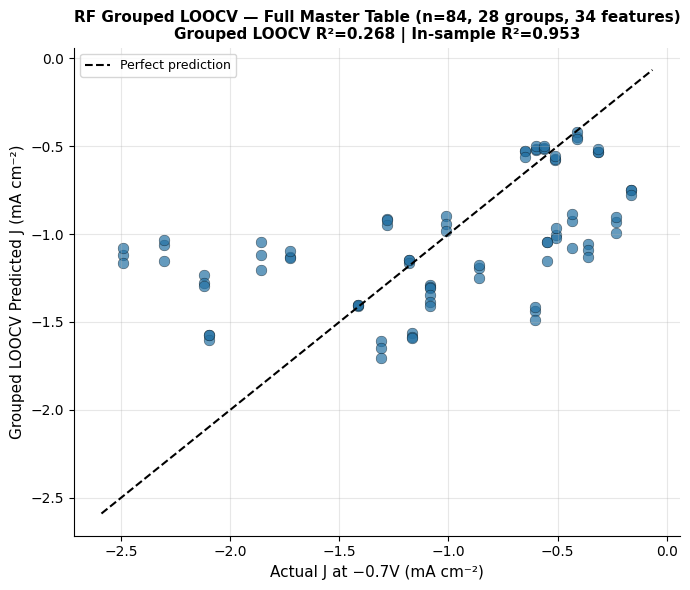

Saved: Results/RF_GroupedLOOCV_actual_vs_predicted.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, y_loo, color="#2471A3", alpha=0.7, s=60, edgecolors="black", linewidths=0.3)
lims = [min(y.min(), y_loo.min()) - 0.1, max(y.max(), y_loo.max()) + 0.1]
ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual J at −0.7V (mA cm⁻²)", fontsize=11)
ax.set_ylabel("Grouped LOOCV Predicted J (mA cm⁻²)", fontsize=11)
ax.set_title(f"RF Grouped LOOCV — Full Master Table (n=84, 28 groups, {len(features)} features)\n"
             f"Grouped LOOCV R²={r2_loo:.3f} | In-sample R²={r2_train:.3f}",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Results/RF_GroupedLOOCV_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Results/RF_GroupedLOOCV_actual_vs_predicted.png")

The predicted-vs-actual scatter visualizes the same gap reported numerically above —
points scatter well off the ideal diagonal, consistent with grouped LOOCV R²=0.27.

## 4. SHAP Feature Attribution (Exploratory)

This SHAP ranking is computed on the full-data RF fit, which does not generalize under
grouped LOOCV (R²=0.27). It describes what the model leans on to fit the training data
— useful for hypothesis generation — but is not a validated, out-of-sample importance
ranking on its own. The validated interpretability result for photocurrent is the
LASSO coefficient analysis in Notebook 05 (grouped LOOCV R²=0.53).

SHAP on the full-data RF fit (exploratory — grouped LOOCV R²=0.27):
Top 15 by mean |SHAP|:
  |tafel|_mV_dec            0.1106
  delta_Rct_mean            0.0489
  Rs_ohm                    0.0474
  Rct_ratio                 0.0382
  Rct_dark                  0.0382
  condition_num             0.0377
  delta_Rs                  0.0372
  CA_stability              0.0312
  Rct_ratio_mean            0.0280
  XRD_metal_tau_nm          0.0220
  SSPL_quenching_ratio      0.0216
  CA_spike_mA               0.0199
  dDeltaRct_dV              0.0199
  Vfb_V                     0.0129
  phase_min                 0.0115


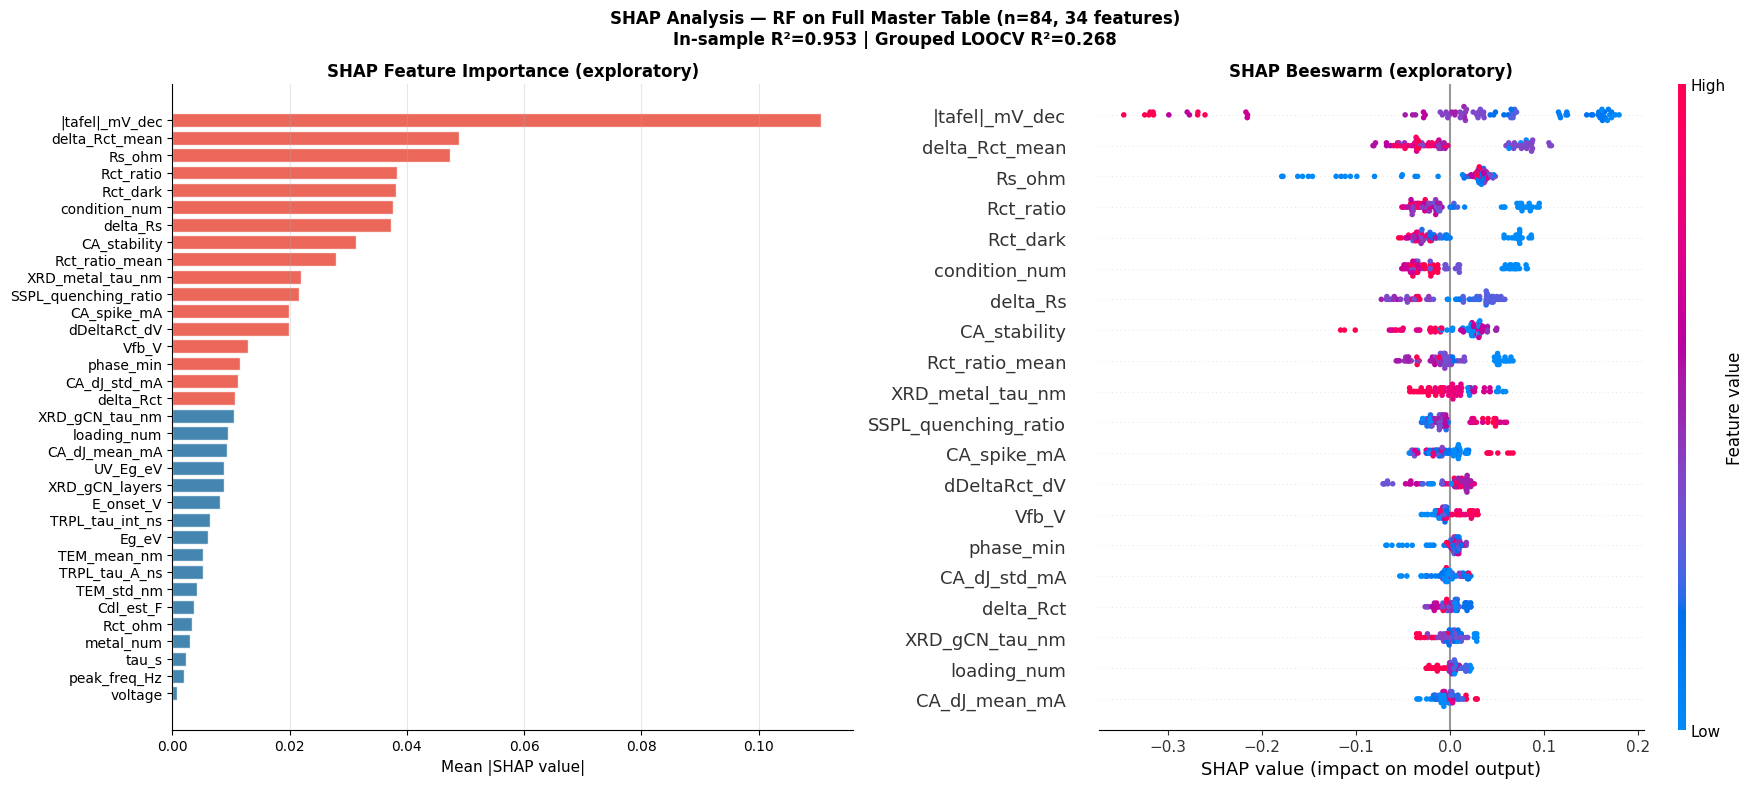


Saved: Results/SHAP_RF_full.png


In [5]:
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X)
mean_shap = np.abs(shap_vals).mean(axis=0)

print("SHAP on the full-data RF fit (exploratory — grouped LOOCV R²=0.27):")
print("Top 15 by mean |SHAP|:")
shap_sorted = sorted(zip(features, mean_shap), key=lambda x: -x[1])
for feat, val in shap_sorted[:15]:
    print(f"  {feat:<25} {val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
sorted_idx = np.argsort(mean_shap)
colors = ["#E74C3C" if mean_shap[i] > np.median(mean_shap) else "#2471A3"
          for i in sorted_idx]
ax1.barh(np.array(features)[sorted_idx], mean_shap[sorted_idx],
         color=colors, alpha=0.85, edgecolor="white")
ax1.set_xlabel("Mean |SHAP value|", fontsize=11)
ax1.set_title("SHAP Feature Importance (exploratory)", fontweight="bold")
ax1.grid(True, alpha=0.3, axis="x")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

ax2 = axes[1]
plt.sca(ax2)
shap.summary_plot(shap_vals, X, feature_names=features, show=False, plot_size=None)
ax2.set_title("SHAP Beeswarm (exploratory)", fontweight="bold")

plt.suptitle(f"SHAP Analysis — RF on Full Master Table (n=84, {len(features)} features)\n"
             f"In-sample R²={r2_train:.3f} | Grouped LOOCV R²={r2_loo:.3f}",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("Results/SHAP_RF_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: Results/SHAP_RF_full.png")

Tafel slope dominates the ranking, followed by a mix of photo-EIS descriptors
(`delta_Rct_mean`, `Rct_ratio`, `Rct_dark`, `delta_Rs`), `Rs_ohm`, and `condition_num`
— broadly consistent with the physical picture of kinetics and LSPR impedance response
driving photocurrent, though this consistency is suggestive rather than confirmatory
given the model's weak out-of-sample performance. This ranking is a reasonable starting
point for hypothesis generation, but the LASSO coefficients in Notebook 05 are the
validated result for this target.

## 5. Partial Dependence Plots (Top 6 Features)

Computed on the same full-data RF fit, so these are read as directional indicators of
how each descriptor relates to photocurrent rather than quantitative, validated
predictions — and partial dependence assumes feature independence, which the
correlated EIS descriptors violate to some degree.

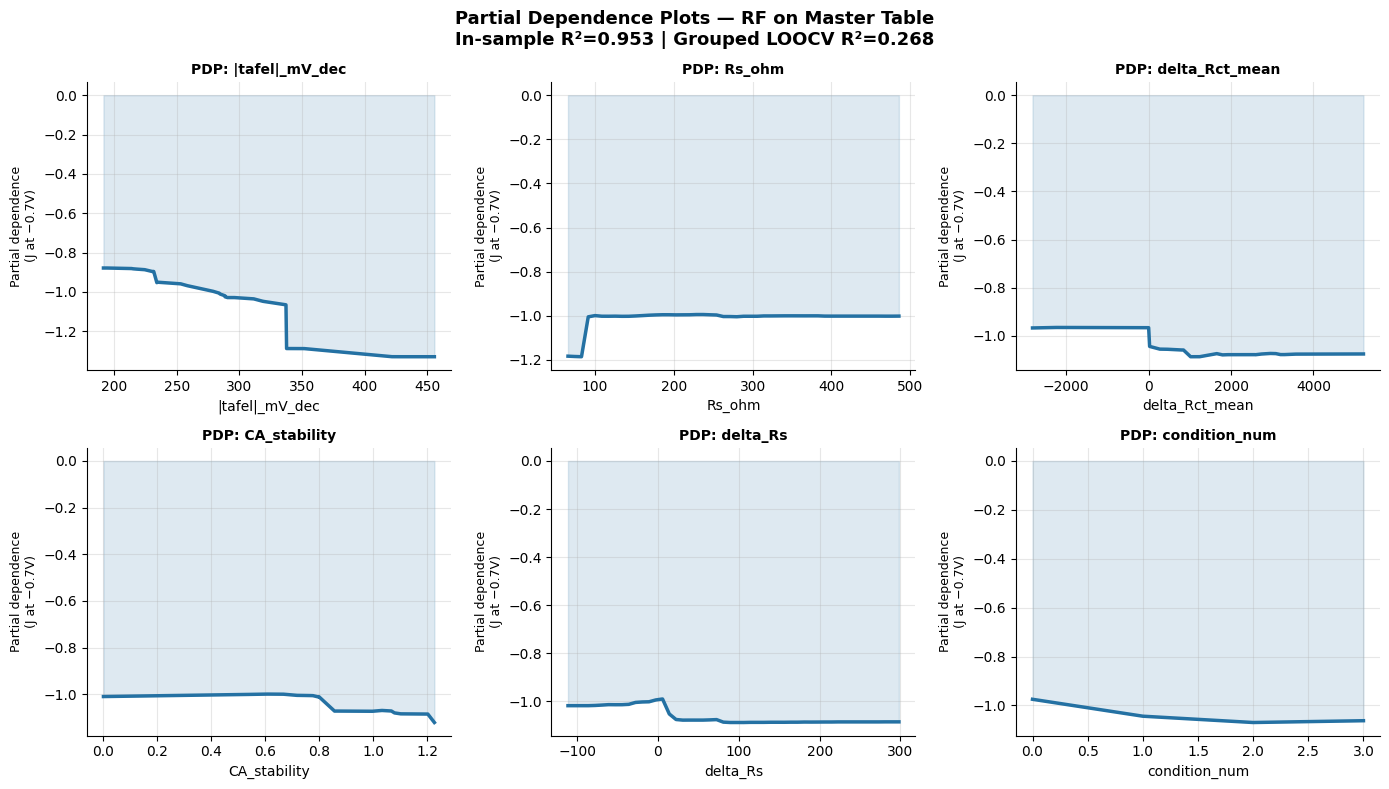

Saved: Results/PDP_RF_master.png


In [6]:
top_features = [f for f, _ in imp[:6]]
top_indices  = [features.index(f) for f in top_features]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat, idx in zip(axes, top_features, top_indices):
    pd_result = partial_dependence(rf, X, features=[idx],
                                   kind="average", grid_resolution=50)
    grid_vals = pd_result.get("grid_values", pd_result.get("values"))[0]
    avg_pred = pd_result["average"][0]

    ax.plot(grid_vals, avg_pred, color="#2471A3", linewidth=2.5)
    ax.fill_between(grid_vals, avg_pred, alpha=0.15, color="#2471A3")
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("Partial dependence\n(J at −0.7V)", fontsize=9)
    ax.set_title(f"PDP: {feat}", fontweight="bold", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle(f"Partial Dependence Plots — RF on Master Table\n"
             f"In-sample R²={r2_train:.3f} | Grouped LOOCV R²={r2_loo:.3f}",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("Results/PDP_RF_master.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Results/PDP_RF_master.png")

**Marginal effect of each feature on J:**

- **Tafel slope** — monotonically decreasing: faster kinetics gives a higher |J|, the
  clearest relationship in the model.
- **Rs_ohm** — a threshold around 100 ohm: below it activity is enabled, above it Rs_ohm
  is largely irrelevant to J.
- **condition_num** — monotonically decreasing across Dark to 410 nm to 440 nm to Full
  spectrum, consistent with the LSV data.
- **CA_stability** — non-monotonic: moderate stability (0.6-0.8) is optimal, with very
  high stability paradoxically corresponding to slower interfacial dynamics.
- **delta_Rct_mean** — slightly increasing: a larger LSPR resistance drop corresponds to
  higher activity.
- **Rct_ratio** — monotonically decreasing: a lower light/dark ratio corresponds to a
  stronger LSPR effect.

## 6. Model Progression Summary

Grouped LOOCV R² for photocurrent (`J_m0p7`) across the models used in this project.

In [7]:
print("="*55)
print("MODEL PROGRESSION — Grouped LOOCV R² for J_m0p7")
print("="*55)
print(f"  Random Forest (full {len(features)}-feature set)   {r2_loo:.3f}")
print("  GPR (full feature set)              see Notebook 05")
print("  LASSO, alpha=0.05 (final)           see Notebook 05")
print()
print(f"Top RF descriptor: Tafel slope (mean |SHAP|={shap_sorted[0][1]:.3f}),")
print("a physically-motivated kinetics descriptor consistent with the")
print("validated LASSO ranking in Notebook 05.")

MODEL PROGRESSION — Grouped LOOCV R² for J_m0p7
  Random Forest (full 34-feature set)   0.268
  GPR (full feature set)              see Notebook 05
  LASSO, alpha=0.05 (final)           see Notebook 05

Top RF descriptor: Tafel slope (mean |SHAP|=0.111),
a physically-motivated kinetics descriptor consistent with the
validated LASSO ranking in Notebook 05.


Random Forest, despite its flexibility, underperforms the linear and Gaussian-process
models on this dataset under grouped LOOCV — consistent with the small number of
independent groups (28) relative to the feature count. The GPR and LASSO comparisons
in Notebook 05 are the validated results for this target.